<a href="https://colab.research.google.com/github/febrianadr/-Credit-Default-Prediction/blob/main/UTS_PMML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Febriana Dwi Rahayu
2404220042

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

random_state = 42

# Import Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

credit_card = pd.read_csv('/content/drive/MyDrive/dataset pmml/UCI_Credit_Card.csv')
credit_card.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [7]:
df = credit_card

# Experiment 0 — Data Understanding & Preparation

## melihat ukuran data

In [8]:
credit_card.shape

(30000, 25)

Dataset terdiri dari 30.000 observasi dan 25 variabel. Dataset ini sesuai dengan ketentuan UTS yang menggunakan 30.000 observasi.

## melihat informasi data

In [9]:
credit_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

Dataset terdiri dari 30.000 baris dan seluruh variabel memiliki 30.000 nilai non-null, sehingga tidak ditemukan missing value. Tipe data terdiri dari numerik integer dan float.

## statistik deskriptif

In [10]:
credit_card.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


Statistik deskriptif digunakan untuk melihat karakteristik umum setiap variabel, seperti nilai minimum, maksimum, rata-rata, dan standar deviasi. Hasil ini juga membantu mengidentifikasi nilai yang perlu diperiksa lebih lanjut sebelum pemodelan.

## mengecek missing value

In [11]:
credit_card.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


Tidak ditemukan missing value pada seluruh variabel sehingga tidak diperlukan metode imputasi.

## mengecek duplicate



In [12]:
credit_card.duplicated().sum()

np.int64(0)

Tidak ditemukan baris duplikat pada dataset sehingga tidak diperlukan penghapusan data duplikat.

## distribusi target

In [13]:
target = 'default.payment.next.month'
print("Nilai unik target:", sorted(credit_card[target].unique()))

credit_card[target].value_counts()

Nilai unik target: [np.int64(0), np.int64(1)]


,count
default.payment.next.month,
0,23364
1,6636


In [14]:
credit_card[target].value_counts(normalize=True) * 100

,proportion
default.payment.next.month,
0,77.88
1,22.12


Target terdiri dari 23.364 nasabah (77,88%) yang tidak mengalami default dan 6.636 nasabah (22,12%) yang mengalami default. Distribusi kelas tidak seimbang karena kelas 0 jauh lebih banyak daripada kelas 1. Oleh karena itu, F1-score digunakan sebagai metrik utama.

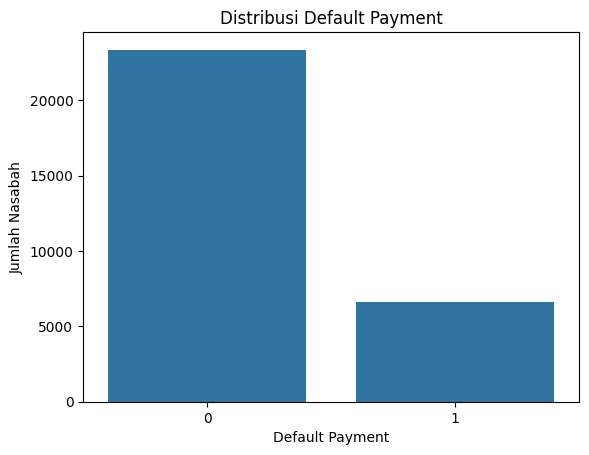

In [15]:
sns.countplot(data=credit_card, x=target)

plt.title('Distribusi Default Payment')
plt.xlabel('Default Payment')
plt.ylabel('Jumlah Nasabah')
plt.show()

In [16]:
for col in ['SEX', 'EDUCATION', 'MARRIAGE',
            'PAY_0', 'PAY_2', 'PAY_3',
            'PAY_4', 'PAY_5', 'PAY_6']:
    print(col, sorted(credit_card[col].unique()))

SEX [np.int64(1), np.int64(2)]
EDUCATION [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
PAY_0 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2

Pemeriksaan nilai dilakukan untuk mengidentifikasi kategori atau kode yang tidak umum. Beberapa variabel memiliki nilai kategori tambahan seperti 0, 4, 5, 6 pada EDUCATION dan 0 pada MARRIAGE, serta nilai -2 dan -1 pada variabel riwayat pembayaran. Nilai tersebut diperiksa sebagai bagian dari data understanding dan tidak langsung dihapus karena dataset digunakan dalam bentuk raw dataset.

## predictor dan target

In [17]:
X = credit_card.drop(columns=['default.payment.next.month', 'ID'])
y = credit_card['default.payment.next.month']

print('Jumlah predictor:', X.shape[1])
print('Jumlah data:', X.shape[0])

Jumlah predictor: 23
Jumlah data: 30000


Variabel target adalah default.payment.next.month, sedangkan 23 variabel lainnya digunakan sebagai predictor. Variabel ID dikeluarkan dari predictor karena hanya merupakan identitas nasabah dan tidak memiliki fungsi sebagai variabel prediktor.

## data training dan testing

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

print('Data training:', X_train.shape)
print('Data testing :', X_test.shape)

Data training: (24000, 23)
Data testing : (6000, 23)


Dataset dibagi menjadi 24.000 data training dan 6.000 data testing dengan proporsi 80:20. Parameter stratify=y digunakan agar proporsi kelas target tetap terjaga pada kedua bagian data.

# Experiment 1 — Baseline

In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

In [20]:
baseline = LogisticRegression(max_iter=2000)

cv_f1 = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

exp1 = {
    'CV F1': cv_f1.mean(),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}

exp1

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

{'CV F1': np.float64(0.33626868025074336),
 'Accuracy': 0.8076666666666666,
 'Precision': 0.6828752642706131,
 'Recall': 0.24340617935192163,
 'F1': 0.35888888888888887}

Logistic Regression digunakan sebagai baseline. Model menghasilkan CV F1 sebesar 0,336269 dan Test F1 sebesar 0,358889. Precision sebesar 0,682875 lebih tinggi dibandingkan Recall sebesar 0,243406, sehingga model masih kurang baik dalam mengenali kelas nasabah yang mengalami default. Hasil ini menjadi acuan untuk eksperimen berikutnya.

# Experiment 2 — Preprocessing

In [21]:
scaled_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

cv_f1 = cross_val_score(
    scaled_model,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

scaled_model.fit(X_train, y_train)

y_pred = scaled_model.predict(X_test)

exp2 = {
    'CV F1': cv_f1.mean(),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}

exp2

{'CV F1': np.float64(0.3646986741176595),
 'Accuracy': 0.8076666666666666,
 'Precision': 0.6868250539956804,
 'Recall': 0.23963828183873398,
 'F1': 0.3553072625698324}

Setelah dilakukan feature scaling, CV F1 meningkat dari 0,336269 menjadi 0,364699 dan Precision meningkat dari 0,682875 menjadi 0,686825. Namun, Test F1 justru turun dari 0,358889 menjadi 0,355307 dan Recall juga sedikit menurun. Jadi, scaling meningkatkan hasil Cross Validation, tetapi belum meningkatkan performa pada test set.

In [22]:
pd.DataFrame(
    [exp1, exp2],
    index=['Experiment 1', 'Experiment 2']
)

,CV F1,Accuracy,Precision,Recall,F1
Experiment 1,0.336269,0.807667,0.682875,0.243406,0.358889
Experiment 2,0.364699,0.807667,0.686825,0.239638,0.355307


# Experiment 3 — Model Comparison

In [23]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        random_state=random_state
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1
    )
}

In [24]:
results = {}

for name, model in models.items():
    cv_f1 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        'CV F1': cv_f1.mean(),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }

comparison = pd.DataFrame(results).T
comparison

,CV F1,Accuracy,Precision,Recall,F1
Logistic Regression,0.364699,0.807667,0.686825,0.239638,0.355307
Decision Tree,0.402027,0.714500,0.369418,0.411454,0.389305
Random Forest,0.478860,0.812333,0.631030,0.364732,0.462273


In [25]:
best_model_name = comparison['CV F1'].idxmax()

print('Model terbaik:', best_model_name)

Model terbaik: Random Forest


Random Forest memberikan CV F1 tertinggi sebesar 0,478860 dan Test F1 tertinggi sebesar 0,462273 dibandingkan dua model lainnya. Random Forest juga memiliki Test Accuracy tertinggi sebesar 0,812333. Meskipun Decision Tree memiliki Recall lebih tinggi, F1-score-nya masih lebih rendah. Oleh karena itu, Random Forest dipilih sebagai model terbaik untuk Experiment 4.

# Experiment 4 — Hyperparameter Tuning

In [26]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [27]:
print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1: 0.48076394900112607


Hasil hyperparameter tuning menggunakan GridSearchCV dengan 5-fold Cross Validation menghasilkan kombinasi parameter terbaik yaitu n_estimators=100, max_depth=None, min_samples_split=2, dan min_samples_leaf=1. Kombinasi tersebut menghasilkan Best CV F1 sebesar 0,480764.

In [28]:
tuned_rf = grid.best_estimator_

y_pred = tuned_rf.predict(X_test)

exp4 = {
    'CV F1': grid.best_score_,
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}

exp4

{'CV F1': np.float64(0.48076394900112607),
 'Accuracy': 0.812,
 'Precision': 0.6324900133155792,
 'Recall': 0.3579502637528259,
 'F1': 0.4571703561116458}

In [34]:
pd.DataFrame(
    [results['Random Forest'], exp4],
    index=['Sebelum tuning', 'Setelah tuning']
).round(6)

,CV F1,Accuracy,Precision,Recall,F1
Sebelum tuning,0.478860,0.812333,0.63103,0.364732,0.462273
Setelah tuning,0.480764,0.812000,0.63249,0.357950,0.457170


Hyperparameter yang diuji: n_estimators (100, 200), max_depth (None, 10, 20), min_samples_split (2, 5), dan min_samples_leaf (1, 2) dengan GridSearchCV 5-fold dan scoring F1. Kombinasi terbaik adalah n_estimators 100, max_depth None, min_samples_split 2, dan min_samples_leaf 1, dengan best CV F1 0,480764. Setelah tuning, CV F1 naik tipis dari 0,478860 menjadi 0,480764, tetapi Test F1 turun dari 0,462273 menjadi 0,457170. Kombinasi terbaik sama dengan nilai default Random Forest, jadi hyperparameter tuning tidak memberikan peningkatan performa yang berarti.

# Experiment 5 — Advanced Model


In [29]:
gb = GradientBoostingClassifier(
    random_state=42
)

cv_f1_gb = cross_val_score(
    gb,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
).mean()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

exp5 = {
    'CV F1': cv_f1_gb,
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1': f1_score(y_test, y_pred_gb)
}

exp5

{'CV F1': np.float64(0.4786017380611874),
 'Accuracy': 0.8183333333333334,
 'Precision': 0.663448275862069,
 'Recall': 0.3624717407686511,
 'F1': 0.46881091617933723}

In [35]:
pd.DataFrame(
    [exp4, exp5],
    index=['Exp 4 Tuned Random Forest', 'Exp 5 Gradient Boosting']
).round(6)

,CV F1,Accuracy,Precision,Recall,F1
Exp 4 Tuned Random Forest,0.480764,0.812000,0.632490,0.357950,0.457170
Exp 5 Gradient Boosting,0.478602,0.818333,0.663448,0.362472,0.468811


Gradient Boosting menghasilkan CV F1 0,478602, sedikit lebih rendah dari Tuned Random Forest (0,480764). Pada test set, Gradient Boosting lebih tinggi pada Accuracy (0,818333 dibanding 0,812000), Precision (0,663448 dibanding 0,632490), Recall (0,362472 dibanding 0,357950), dan F1 (0,468811 dibanding 0,457170). Selisih CV F1 sangat kecil, sedangkan Test F1 naik sekitar 0,0116. Model advanced memberikan hasil sedikit lebih baik pada test set, tetapi tidak jauh berbeda dari Random Forest.

 # Summary of Experiment Results

In [33]:
final_summary = pd.DataFrame([
    {
        'Experiment': '1 - Baseline',
        'Model': 'Logistic Regression',
        'CV F1': exp1['CV F1'],
        'Test Accuracy': exp1['Accuracy'],
        'Test Precision': exp1['Precision'],
        'Test Recall': exp1['Recall'],
        'Test F1': exp1['F1']
    },
    {
        'Experiment': '2 - Preprocessing',
        'Model': 'Logistic Regression + Scaling',
        'CV F1': exp2['CV F1'],
        'Test Accuracy': exp2['Accuracy'],
        'Test Precision': exp2['Precision'],
        'Test Recall': exp2['Recall'],
        'Test F1': exp2['F1']
    },
    {
        'Experiment': '3 - Model Comparison',
        'Model': 'Random Forest',
        'CV F1': comparison.loc['Random Forest', 'CV F1'],
        'Test Accuracy': comparison.loc['Random Forest', 'Accuracy'],
        'Test Precision': comparison.loc['Random Forest', 'Precision'],
        'Test Recall': comparison.loc['Random Forest', 'Recall'],
        'Test F1': comparison.loc['Random Forest', 'F1']
    },
    {
        'Experiment': '4 - Hyperparameter Tuning',
        'Model': 'Tuned Random Forest',
        'CV F1': exp4['CV F1'],
        'Test Accuracy': exp4['Accuracy'],
        'Test Precision': exp4['Precision'],
        'Test Recall': exp4['Recall'],
        'Test F1': exp4['F1']
    },
    {
        'Experiment': '5 - Advanced Model',
        'Model': 'Gradient Boosting',
        'CV F1': exp5['CV F1'],
        'Test Accuracy': exp5['Accuracy'],
        'Test Precision': exp5['Precision'],
        'Test Recall': exp5['Recall'],
        'Test F1': exp5['F1']
    }
])

final_summary.round(6)

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1 - Baseline,Logistic Regression,0.336269,0.807667,0.682875,0.243406,0.358889
1,2 - Preprocessing,Logistic Regression + Scaling,0.364699,0.807667,0.686825,0.239638,0.355307
2,3 - Model Comparison,Random Forest,0.478860,0.812333,0.631030,0.364732,0.462273
3,4 - Hyperparameter Tuning,Tuned Random Forest,0.480764,0.812000,0.632490,0.357950,0.457170
4,5 - Advanced Model,Gradient Boosting,0.478602,0.818333,0.663448,0.362472,0.468811


Berdasarkan seluruh eksperimen, Gradient Boosting dipilih sebagai model final karena menghasilkan Test F1 tertinggi sebesar 0,468811, disertai Test Accuracy 0,818333 dan Precision 0,663448. Meskipun Tuned Random Forest memiliki CV F1 sedikit lebih tinggi, performanya pada test set lebih rendah. Oleh karena itu, pemilihan model final didasarkan pada hasil evaluasi test set dengan F1-score sebagai metrik utama.